# Netflix Data Analysis

### Libraries Used

* **Pandas:** Data cleaning and analysis
* **NumPy:** Numerical operations
* **Matplotlib:** Data visualization
* **Seaborn:** Statistical visualizations
* **pandasql:** SQL queries on thedataset


In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignore FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# Load the Netflix dataset
df = pd.read_csv("netflix.csv")

# Show the first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
print(df.shape)  # Check the number of rows and columns

(8807, 12)


In [4]:
df.info()  # Check column names, data types, and non-null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
print(df.describe())  # Get summary statistics for numerical columns

       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000


In [6]:
print(df.duplicated().sum())  # Count duplicate rows

0


In [7]:
nf = df.copy()  # Create a copy of the dataset for cleaning

In [8]:
nf.dtypes  # Check the data type of each column

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [9]:
print(nf.isna().sum())  # Count missing values in each column

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [10]:
# Fill missing values in selected columns
nf["director"] = nf["director"].fillna("Unknown")
nf["cast"] = nf["cast"].fillna("Unknown")
nf["country"] = nf["country"].fillna("Unknown")
nf["rating"] = nf["rating"].fillna("Not Rated")
nf["duration"] = nf["duration"].fillna("Unknown")

In [11]:
# Convert date_added to a date format
nf["date_added"] = pd.to_datetime(nf["date_added"], errors="coerce")

In [12]:
print(nf.isna().sum())  # Check missing values after cleaning

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64


In [13]:
# Set colours for charts
colors = ["skyblue", "orange", "lightgreen", "salmon", "plum",
          "gold", "coral", "lightseagreen", "pink", "lightgray"]

### 1. How many Movies and TV Shows are on Netflix?

In [14]:
# Count Netflix titles by type
total_titles = nf["type"].count()
titles_by_type = nf["type"].value_counts()

print(f"Total titles on Netflix: {total_titles}")
print(f"Titles by type:\n{titles_by_type}")

Total titles on Netflix: 8807
Titles by type:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


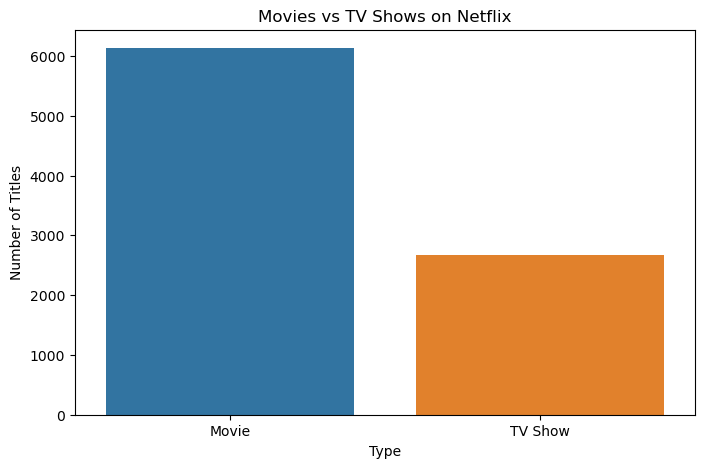

In [15]:
# Compare the number of Movies and TV Shows
plt.figure(figsize=(8, 5))
sns.countplot(data=nf, x="type")

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Number of Titles")

plt.show()

### 2. What are the top 10 genres on Netflix?

In [16]:
# Find the top 10 genres on Netflix
genres = nf["listed_in"].dropna().str.split(", ").explode()
top_10_genres = genres.value_counts().head(10)

print(top_10_genres)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


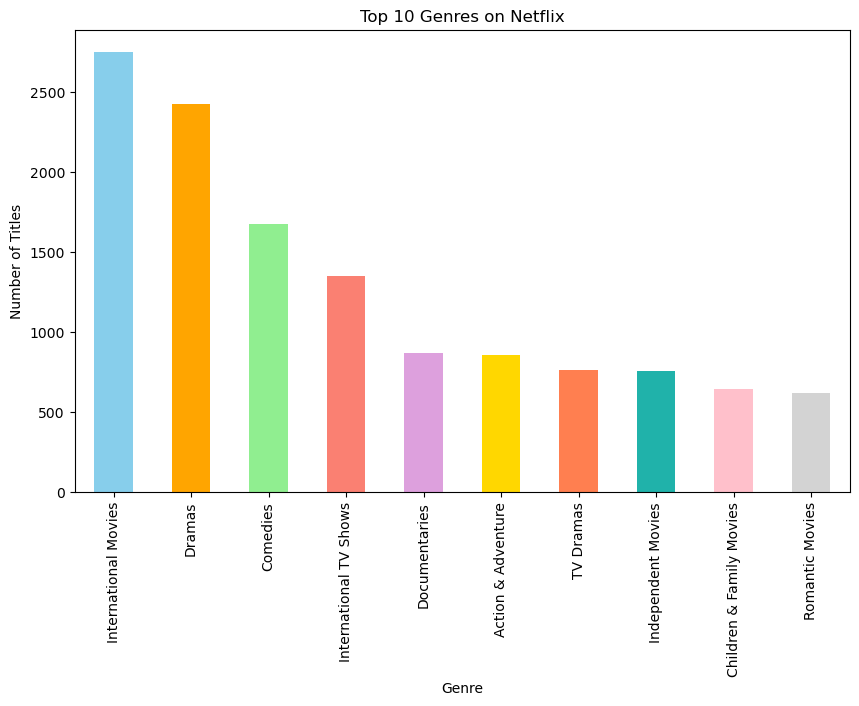

In [17]:
# Plot the top 10 genres on Netflix
plt.figure(figsize=(10, 6))
top_10_genres.plot(kind="bar", color=colors)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.xticks(rotation=90)

plt.show()

### 3(a). Which country produce the most Netflix content?

In [18]:
# Find the country with the most titles
top_prod_country = nf["country"].value_counts().idxmax()

print(f"Top producing country: {top_prod_country}")

Top producing country: United States


### 3(b). Which 10 countries have the most Netflix titles?

In [19]:
# Count each country separately
countries = nf["country"].dropna().str.split(", ").explode()
top_10_countries = countries.value_counts().head(10)

print(top_10_countries)

country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64


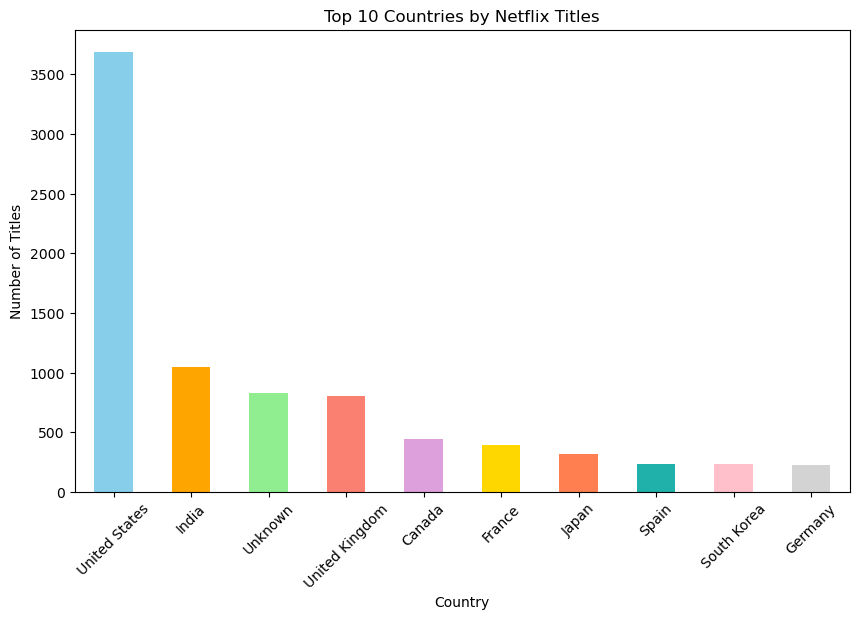

In [20]:
# Plot the top 10 countries by number of titles
plt.figure(figsize=(10, 6))
top_10_countries.plot(kind="bar", color=colors)

plt.title("Top 10 Countries by Netflix Titles")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

### 4. How has the number of Netflix titles changed over the years?

In [21]:
# Count titles added to Netflix each year
each_year = nf.groupby(nf["date_added"].dt.year)["title"].count()
each_year = each_year.sort_index()

each_year

date_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: title, dtype: int64

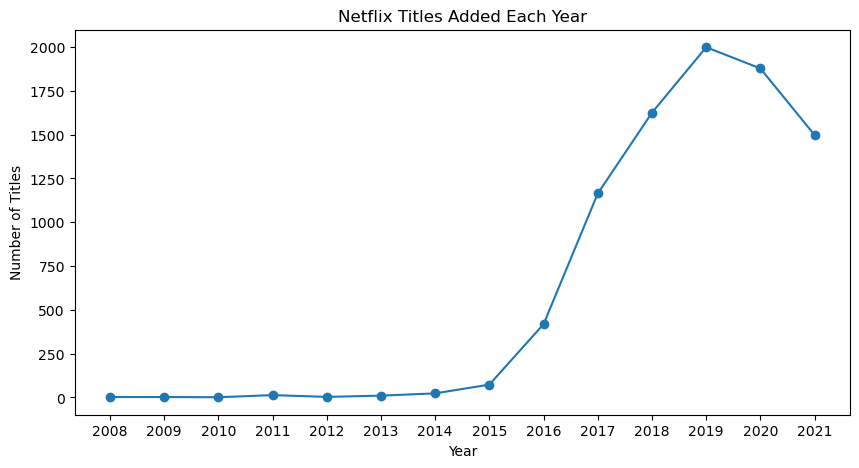

In [22]:
# Plot the number of titles added each year
plt.figure(figsize=(10, 5))
each_year.plot(kind="line", marker="o")

plt.title("Netflix Titles Added Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.xticks(each_year.index.astype(int))

plt.show()

### 5. How do ratings differ between Movies and TV Shows?

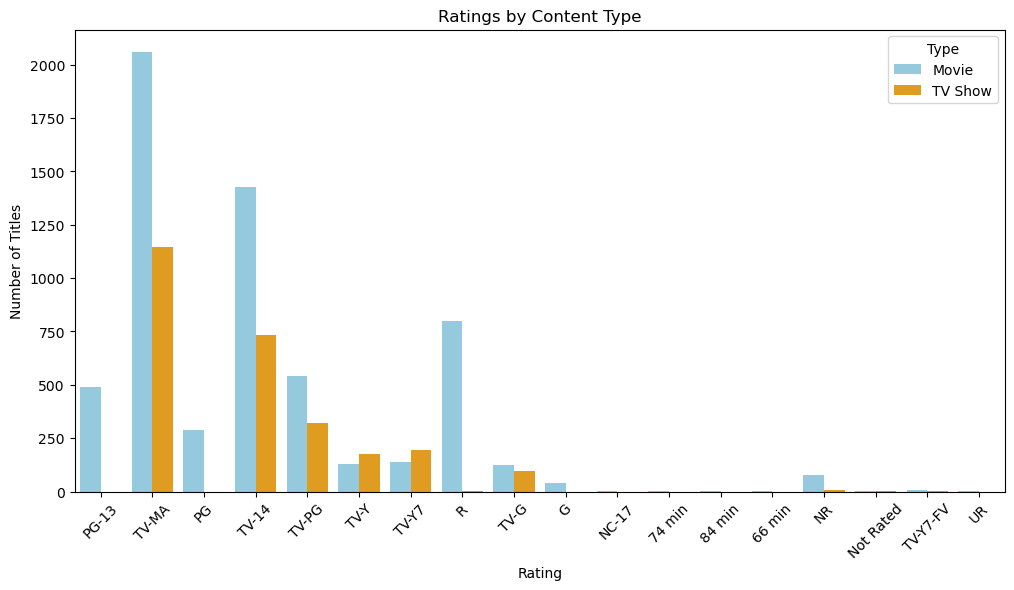

In [23]:
# Compare ratings for Movies and TV Shows
plt.figure(figsize=(12, 6))

sns.countplot(data=nf, x="rating", hue="type", palette=colors[:2])

plt.title("Ratings by Content Type")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.legend(title="Type")

plt.show()

### 6. What is the average duration of Netflix Movies?

In [24]:
# Select only Movies
movies = nf[nf["type"] == "Movie"].copy()

In [25]:
# Convert movie duration to minutes
movies["duration_min"] = pd.to_numeric(
    movies["duration"].str.replace(" min", ""),
    errors="coerce"
)

In [26]:
# Calculate the average movie duration
avg_duration = movies["duration_min"].mean()

print(f"Average movie duration: {round(avg_duration, 2)} minutes")

Average movie duration: 99.58 minutes


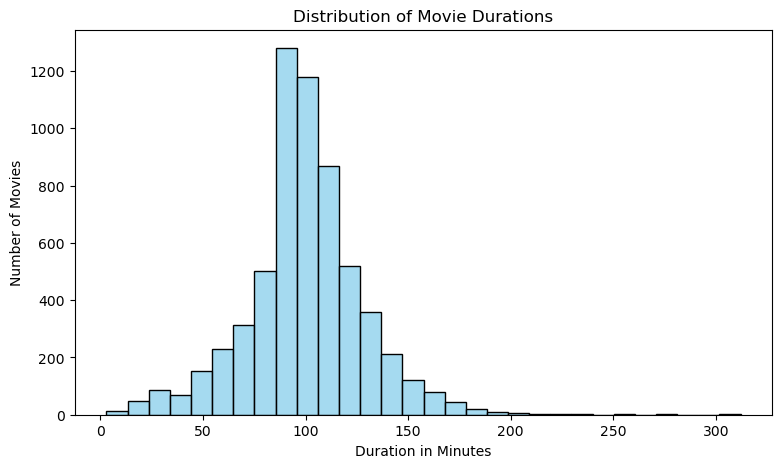

In [27]:
# Show the distribution of movie durations
plt.figure(figsize=(9, 5))

sns.histplot(data=movies, x="duration_min", bins=30, color=colors[0])

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration in Minutes")
plt.ylabel("Number of Movies")

plt.show()

### 7. Which directors have the most titles?

In [28]:
# Find the top 10 directors by number of titles
top_10_directors = nf["director"].value_counts().drop("Unknown").head(10)

print(top_10_directors)

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Jay Chapman               12
Youssef Chahine           12
Martin Scorsese           12
Steven Spielberg          11
Name: count, dtype: int64


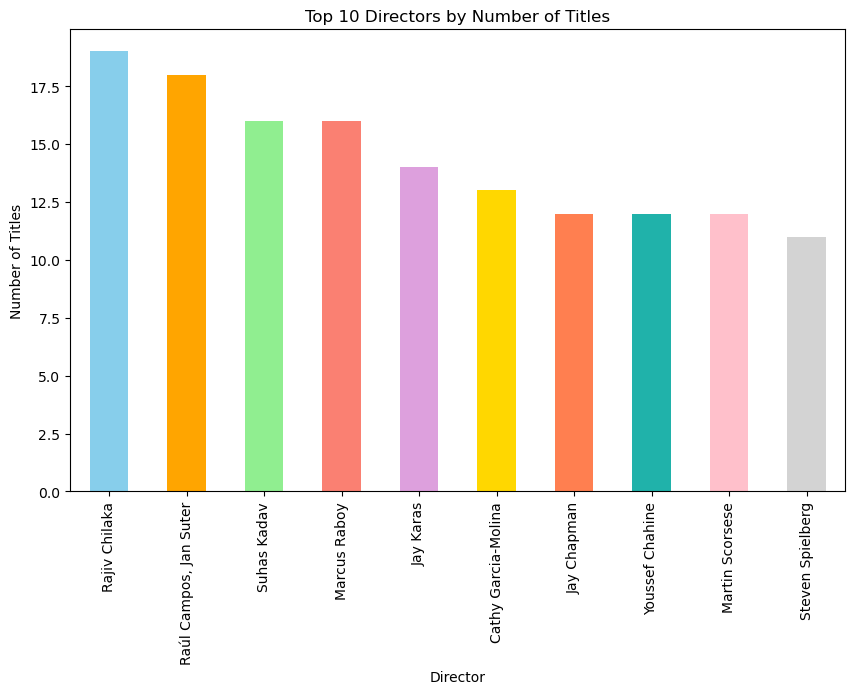

In [29]:
# Plot the top 10 directors by number of titles
plt.figure(figsize=(10, 6))
top_10_directors.plot(kind="bar", color=colors)

plt.title("Top 10 Directors by Number of Titles")
plt.xlabel("Director")
plt.ylabel("Number of Titles")
plt.xticks(rotation=90)

plt.show()

### 8. Which actors appear most frequently?

In [30]:
# Find the top 10 actors by number of titles
actors = nf["cast"].dropna().str.split(", ").explode()
top_10_actors = actors.value_counts().drop("Unknown").head(10)

top_10_actors

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Amitabh Bachchan    28
Name: count, dtype: int64

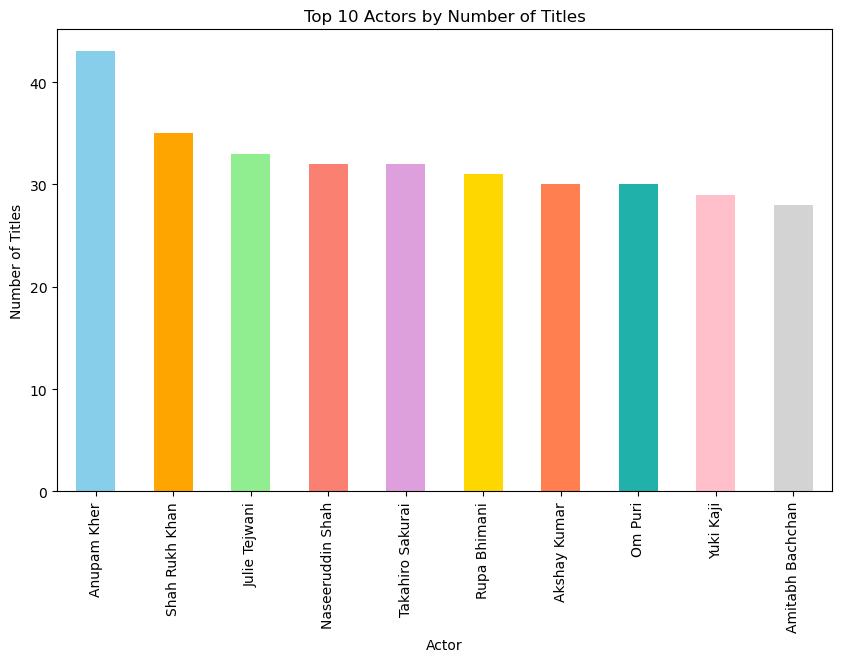

In [31]:
# Plot the top 10 actors by number of titles
plt.figure(figsize=(10, 6))
top_10_actors.plot(kind="bar", color=colors)

plt.title("Top 10 Actors by Number of Titles")
plt.xlabel("Actor")
plt.ylabel("Number of Titles")
plt.xticks(rotation=90)

plt.show()

# SQL Analysis

In [32]:
!pip install pandasql

In [33]:
# Import the SQL query function
from pandasql import sqldf

In [34]:
# Display the first 5 rows using SQL
query = """
SELECT *
FROM nf
LIMIT 5
"""

sqldf(query, locals())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25 00:00:00.000000,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24 00:00:00.000000,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24 00:00:00.000000,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24 00:00:00.000000,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24 00:00:00.000000,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### 1. How many titles were added after 2020 by type?

In [35]:
# Count titles added from 2020 onward by type
query = """
SELECT type, COUNT(*) AS total_titles
FROM nf
WHERE date_added >= '2020-01-01'
GROUP BY type
ORDER BY total_titles DESC
"""

sqldf(query, locals())

,type,total_titles
0,Movie,2277
1,TV Show,1099


### 2. What is the oldest movie in the dataset?

In [36]:
# Find the oldest movie on Netflix by release year
query = """
SELECT title AS oldest_movie, release_year AS year
FROM nf
WHERE type = 'Movie'
ORDER BY release_year ASC
LIMIT 1
"""

sqldf(query, locals())

,oldest_movie,year
0,Prelude to War,1942


### 3. What are the earliest and latest release years for each content type?

In [37]:
# Find the earliest and latest release years for each content type
query = """
SELECT
    type,
    MIN(release_year) AS earliest_year,
    MAX(release_year) AS latest_year
FROM nf
GROUP BY type
"""

sqldf(query, locals())

,type,earliest_year,latest_year
0,Movie,1942,2021
1,TV Show,1925,2021


### 4. Which year had the highest number of Netflix titles released?

In [38]:
# Find the year with the most titles released
query = """
SELECT release_year, COUNT(*) AS total_titles
FROM nf
GROUP BY release_year
ORDER BY total_titles DESC
LIMIT 1
"""

sqldf(query, locals())

,release_year,total_titles
0,2018,1147
